In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

conn=sqlite3.connect('speedtest_results.db')
df = pd.read_sql_query("SELECT * FROM results", conn)
mean_download = df['download'].mean()
mean_upload = df['upload'].mean()
mean_ping=df['ping'].mean()
standard_deviation_latency = df['ping'].std()
threshold=mean_ping+(3*standard_deviation_latency)
mask=df['ping'] > threshold
outliers = df[mask]
print("Outliers in Latency:")
print(outliers)
df_cleaned = df[~mask]
fastest_download = df_cleaned['download'].max()
slowest_download = df_cleaned['download'].min()
fastest_upload = df_cleaned['upload'].max()
slowest_upload = df_cleaned['upload'].min()
print(f"Average Download Speed: {mean_download:.2f} Mbps")
print(f"Average Upload Speed: {mean_upload:.2f} Mbps")
print(f"Fastest Download Speed: {fastest_download:.2f} Mbps")
print(f"Slowest Download Speed: {slowest_download:.2f} Mbps")
print(f"Fastest Upload Speed: {fastest_upload:.2f} Mbps")
print(f"Slowest Upload Speed: {slowest_upload:.2f} Mbps")
print(f"Standard Deviation of Latency: {standard_deviation_latency:.2f} ms")
print(f"Original count of records: {len(df)}")
print(f"Count of cleaned records: {len(df_cleaned)}")

print("\n--- Additional Insights ---")

print("Median Download:", df['download'].median())
print("95th Percentile Download:", df['download'].quantile(0.95))
print("Worst 5% Download:", df['download'].quantile(0.05))

print("Average Ping:", df['ping'].mean())
print("Max Ping:", df['ping'].max())
conn.close()

Outliers in Latency:
                      timestamp  download    upload    ping
10   2026-02-20T12:38:45.037511  3.454742  8.276403  24.905
94   2026-02-20T17:36:45.671777  5.534030  9.498987  24.251
140  2026-02-20T18:52:52.375386  4.521022  7.766742  22.629
Average Download Speed: 8.98 Mbps
Average Upload Speed: 8.85 Mbps
Fastest Download Speed: 9.76 Mbps
Slowest Download Speed: 0.78 Mbps
Fastest Upload Speed: 9.98 Mbps
Slowest Upload Speed: 3.18 Mbps
Standard Deviation of Latency: 1.89 ms
Original count of records: 226
Count of cleaned records: 223

--- Additional Insights ---
Median Download: 9.571108011712823
95th Percentile Download: 9.728643520523942
Worst 5% Download: 5.398093901019959
Average Ping: 16.721477876106196
Max Ping: 24.905



--- Daily Averages ---
Daily Average Download Speed:
timestamp
2026-02-19    9.527267
2026-02-20    9.014669
2026-02-21    9.613916
Name: download, dtype: float64
Daily Average Upload Speed:
timestamp
2026-02-19    8.668486
2026-02-20    8.869297
2026-02-21    9.618168
Name: upload, dtype: float64
Daily Average Ping:
timestamp
2026-02-19    15.936286
2026-02-20    16.667000
2026-02-21    14.525632
Name: ping, dtype: float64
Records with ping greater than 20 ms:
                      timestamp  download    upload    ping
10   2026-02-20T12:38:45.037511  3.454742  8.276403  24.905
42   2026-02-20T13:27:57.943447  8.958440  8.936987  20.117
51   2026-02-20T13:40:32.791574  9.520014  9.026877  20.185
53   2026-02-20T13:43:19.574424  9.678134  8.475509  20.464
69   2026-02-20T15:36:07.456774  9.460966  8.746144  22.016
87   2026-02-20T17:26:51.572953  7.726715  9.600167  20.391
89   2026-02-20T17:29:37.762607  9.342266  9.512266  20.749
94   2026-02-20T17:36:45.671777  5.534030  9.498987  

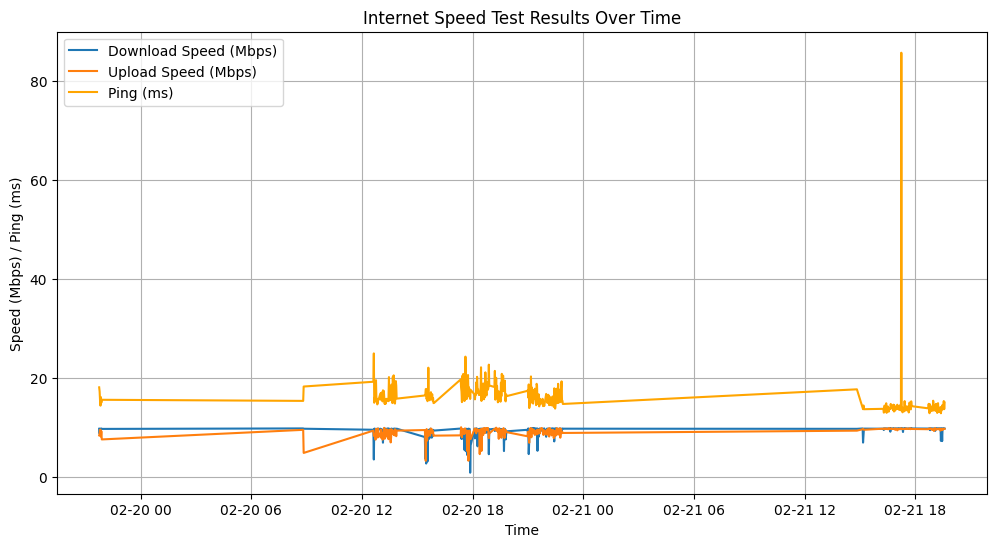

In [11]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
conn = sqlite3.connect('speedtest_results.db')
df = pd.read_sql_query("SELECT * FROM results", conn)
fast_downloads=df[df["ping"]>20]
df['timestamp'] = pd.to_datetime(df['timestamp'])

daily_avg_download = df.groupby(df['timestamp'].dt.date)['download'].mean()
daily_avg_upload = df.groupby(df['timestamp'].dt.date)['upload'].mean()
daily_avg_ping = df.groupby(df['timestamp'].dt.date)['ping'].mean()
df['download_MBps'] = df['download'] / 8
print("\n--- Daily Averages ---")
print(f"Daily Average Download Speed:\n{daily_avg_download}")
print(f"Daily Average Upload Speed:\n{daily_avg_upload}")
print(f"Daily Average Ping:\n{daily_avg_ping}")

print("Records with ping greater than 20 ms:")
print(fast_downloads)

print("The speed in MB/S")
print(df['download_MBps'])

def classify(row):
    if row['download']< 5:
        return 'Poor'
    elif row['download'] < 8:
        return 'Average'
    else:        
        return 'Good'

df['download_category'] = df.apply(classify, axis=1)
print("\n--- Download Categories ---")
print(df['download_category'].value_counts())
def classify_ping(row):
    if row['ping'] < 15:
        return 'Low'
    elif row['ping'] < 30:
        return 'Medium'
    else:        
        return 'High'
df['ping_category'] = df.apply(classify_ping, axis=1)
print("\n--- Ping Categories ---")
print(df['ping_category'].value_counts())    

df = df.sort_values('timestamp')
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['download'] , label='Download Speed (Mbps)')
plt.plot(df['timestamp'], df['upload'] , label='Upload Speed (Mbps)')
plt.plot(df['timestamp'], df['ping'], label='Ping (ms)', color='orange')
plt.xlabel('Time')
plt.ylabel('Speed (Mbps) / Ping (ms)')
plt.title('Internet Speed Test Results Over Time')
plt.legend()
plt.grid()
plt.show()





Latency Consistency (Standard Deviation): 1.88 ms
Daily Average Download Speeds:
date
2026-02-19    9.527267
2026-02-20    8.988707
Name: download, dtype: float64


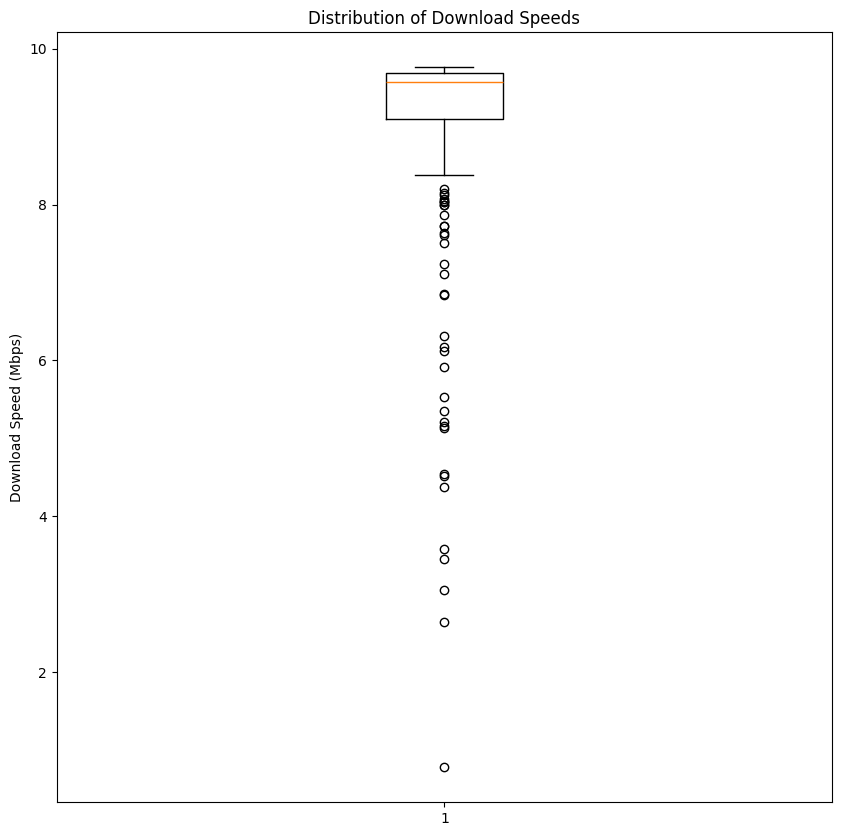

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
conn = sqlite3.connect('speedtest_results.db')
df = pd.read_sql_query("SELECT * FROM results", conn)
#convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
conn.close()

#CALCULATE DYNAMICS (PILLAR 1&2)
#The "Stability" principle:standard deviation
ping_std = df['ping'].std()
print(f"Latency Consistency (Standard Deviation): {ping_std:.2f} ms")

#SPLIT-APPLY-COMBINE (PILLAR 3)
#Group by day and calculate mean download speed 
df['date'] = df['timestamp'].dt.date
daily_download_means = df.groupby('date')['download'].mean()
print("Daily Average Download Speeds:")
print(daily_download_means)

#VISUALIZATION (PILLAR 4)(The Box plot)
plt.figure(figsize=(10, 10))
plt.boxplot(df['download'])
plt.title("Distribution of Download Speeds")
plt.ylabel("Download Speed (Mbps)")
plt.show()

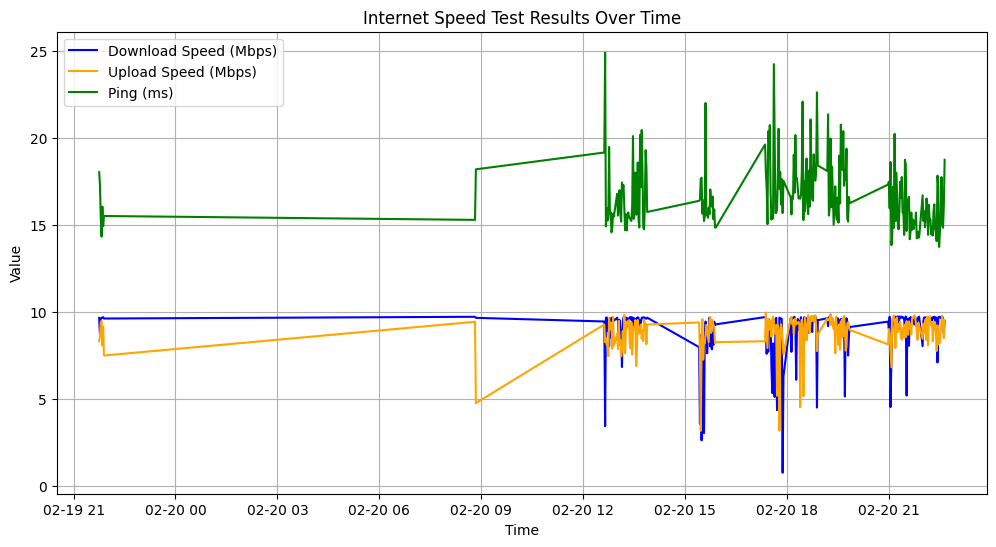

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
conn = sqlite3.connect('speedtest_results.db')
df = pd.read_sql_query("SELECT * FROM results", conn)
#draw graph of download, upload and ping over time
df['timestamp'] = pd.to_datetime(df['timestamp'])
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['download'], label='Download Speed (Mbps)', color='blue')
plt.plot(df['timestamp'], df['upload'], label='Upload Speed (Mbps)', color='orange')
plt.plot(df['timestamp'], df['ping'], label='Ping (ms)', color='green')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Internet Speed Test Results Over Time')
plt.legend()
plt.grid()
plt.show()